In [12]:
from FormUtils import pyForm, capture_physics_expr

In [13]:
%%pyForm Rutherfoed

* Process: Rutherford

#-
* Above suppresses extra output
Off Statistics;
Off FinalStats;

#include SquareAmplitude.h

* Physical constants
Symbols e, pi, alpha, Mproton, x;

Local M =     (e^2) * (UB(i1, p3, 0) * g(i1, i2, mu1) * U(i2, p1, 0)) 
                    * phprop(mu1, mu2, q)  
                    * (UB(i3, p4, Mproton) * g(i3, i4, mu2) * U(i4, p2, Mproton));
#call squareamplitude(M, Msq)
.sort

* Spin averaging (1/2 * 1/2)
multiply 1/4; 
* coupling
id e^4 = 16 * pi^2 * alpha^2;
* propagator handling
id prop(x?) = (x)^-1;
id (q.q)^-1 = (t)^-1;
repeat;
    id q = p1 - p3;
endrepeat;
.sort

* Kinematics 
#call Mandelstam2To2(p1,p2,p3,p4,0,Mproton,0,Mproton)

* Further clean up
id u = 2*Mproton^2 - s - t;

bracket alpha, s;
.sort
* Save
Format C;
#write <Rutherford.txt> "%e;", Msq;
.sort
* Print
Format;
Print Msq;
.end

FORM 5.0.0 (Jan 27 2026, v5.0.0)                 Run: Wed Apr 15 19:26:38 2026
    
    * Process: Rutherford
    
    #-

   Msq =
      64*t^(-2)*pi^2*alpha^2*Mproton^4 + 32*pi^2*alpha^2 - 128*s*t^(-2)*pi^2*
      alpha^2*Mproton^2 + 64*s*t^(-1)*pi^2*alpha^2 + 64*s^2*t^(-2)*pi^2*
      alpha^2;




<|M^2|> =  32*pi**2*alpha**2*(2*Mproton**4 + 2*s**2 - 2*s*(2*Mproton**2 - t) + t**2)/t**2
dsigma/dOmega =  alpha**2*(8*E1**4*sin(theta/2)**4 - 2*(2*E1 + Mproton)*(-2*E1*sin(theta/2)**2 - Mproton)*(E1**2*cos(theta) - E1**2 + Mproton*(-2*E1*sin(theta/2)**2 - Mproton)) + (Mproton**2 + (2*E1 + Mproton)**2)*(-2*E1*sin(theta/2)**2 - Mproton)**2)/(16*E1**4*(-2*E1*sin(theta/2)**2 - Mproton)**2*sin(theta/2)**4)
static limit =  alpha**2*(cos(theta) + 1)/(8*E1**2*sin(theta/2)**4)
mott =  alpha**2*cos(theta/2)**2/(4*E1**2*sin(theta/2)**4)
Rutherford Limit: alpha**2/(4*E1**2*sin(theta/2)**4)


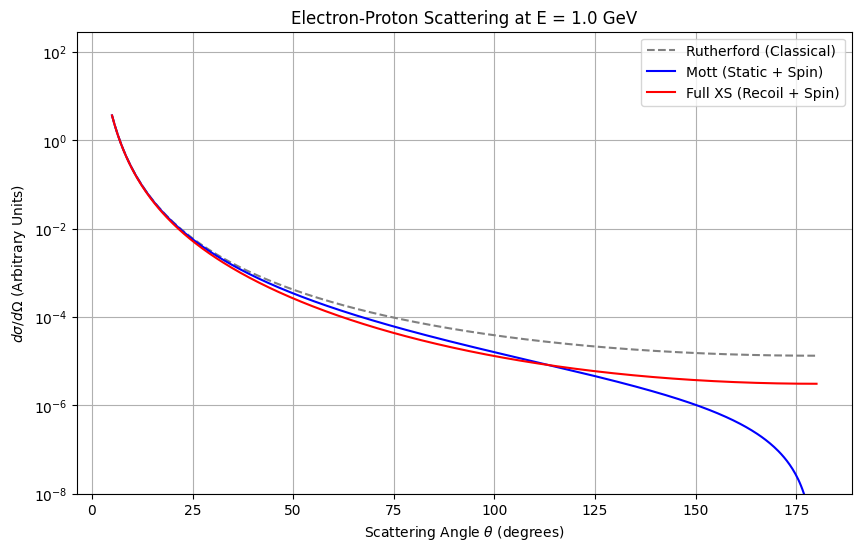

In [37]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from Kinematics import XS_FixedTarget_Lab

plt.style.use("seaborn-v0_8-muted")
plt.rcParams["axes.grid"] = True


# Capture Raw FORM ouput
form_expr = capture_physics_expr("scripts/Rutherford.txt")
# Convert FORM to sympy
s, t, u, alpha, Mproton = sp.symbols("s t u alpha Mproton")
Msq = sp.simplify(form_expr)
print(f"<|M^2|> =  {Msq}")

# Call the method to get the xs in CM
theta = sp.Symbol("theta", real=True)
E1 = sp.Symbol("E1", positive=True)
xs_raw = XS_FixedTarget_Lab(Msq, s, t, u, theta, E1, me)

half_theta = theta / 2
xs = (
    xs_raw.replace(sp.cos(theta) + 1, 2 * sp.cos(theta / 2) ** 2)
    .replace(1 + sp.cos(theta), 2 * sp.cos(theta / 2) ** 2)
    .replace(sp.cos(theta) - 1, -2 * sp.sin(theta / 2) ** 2)
    .replace(1 - sp.cos(theta), 2 * sp.sin(theta / 2) ** 2)
)
print(f"dsigma/dOmega =  {xs}")

# limit of proton being static
static = sp.simplify(sp.limit(xs, Mproton, sp.oo))
print(f"static limit =  {static}")

# replacement to look more like text bookl
mott = sp.simplify(static.replace(sp.cos(theta) + 1, 2 * sp.cos(theta / 2) ** 2))
print(f"mott =  {mott}")

# spin effect goes to 1 , Rutherford
rutherford = mott.subs(sp.cos(theta / 2), 1)
print(f"Rutherford Limit: {rutherford}")

coords = (E1, alpha, Mproton, theta)
xs_func = sp.lambdify(coords, xs, "numpy")
mott_func    = sp.lambdify(coords, mott, "numpy")
ruth_func    = sp.lambdify(coords, rutherford, "numpy")

E_val = 1.0      # GeV (Electron beam energy)
alpha_val = 1/137
M_val = 0.938    # GeV (Proton mass)

# prevent division by zero in 1/sin^4
theta_deg = np.linspace(5, 180, 500) 
theta_rad = np.radians(theta_deg)

# 3. Calculate values
# We pass (E, alpha, M, theta) to each
y_full = xs_func(E_val, alpha_val, M_val, theta_rad)
y_mott = mott_func(E_val, alpha_val, M_val, theta_rad)
y_ruth = ruth_func(E_val, alpha_val, M_val, theta_rad)

# 4. Plotting
plt.figure(figsize=(10, 6))

plt.plot(theta_deg, y_ruth, '--', label='Rutherford (Classical)', color='gray')
plt.plot(theta_deg, y_mott, '-',  label='Mott (Static + Spin)', color='blue')
plt.plot(theta_deg, y_full, '-',  label='Full XS (Recoil + Spin)', color='red')
plt.yscale('log') 
plt.xlabel(r'Scattering Angle $\theta$ (degrees)')
plt.ylabel(r'$d\sigma/d\Omega$ (Arbitrary Units)')
plt.title(f'Electron-Proton Scattering at E = {E_val} GeV')
plt.legend()
plt.ylim(bottom=1e-8) 

plt.show()

